## Practice loading data in Pandas

Read in the the data in grades_dataset.csv as a Pandas dataframe.

Save the labels in column 'Grade>90' as a numpy array and name it 'y'  Use the label_names included below as the names for the 2 classes (just don't delete this line, your code will use it later).

Save the names of all of the other columns as a numpy array named feature_names.  Save the data in those columns as a numpy array named X.

In [3]:
label_names = [ 'Grade<=90' , 'Grade>90' ] ##Don't delete this
import pandas as pd
import numpy as np # import the necessary packages

data = pd.read_csv("grades_dataset.csv") # read the .csv file in as a DataFrame and assign it to a variable named data
y = data['Grade>90'].to_numpy() # save the labels in the prescribed column as a numoy array
print(y) # print the data in an array 
feature_names= data.drop(columns=['Grade>90']) #save the other columns in the same format
X= feature_names.to_numpy() #take the feature names and turn them into a numpy array, call it 'x'
print(X) # print that data


[0. 1. 1. ... 0. 1. 0.]
[[ 3. 81. 70. ...  1.  0.  0.]
 [ 3. 79. 83. ...  1.  0.  0.]
 [ 1. 75. 75. ...  1.  0.  0.]
 ...
 [ 7. 57. 56. ...  1.  0.  0.]
 [ 2. 75. 75. ...  0.  0.  1.]
 [ 3. 84. 81. ...  0.  0.  1.]]


## Practice preprocessing data 

Generate 3 sets of indices corresponding to the train, valid and test sets.  The train set should be 60% of the data, the valid set should be 20% of the data and the test set should also be 20% of the data.  These sets should be random and shouldn't overlap.  Generate them by using scikit-learn's train_test_split function twice -- first to split out the test set, then to split the remaining indices into the train and valid set.  

Then scale the data using scikit-learn's StandardScaler.  You should fit the scaler on the train set only, then scale all of the data using it.

In [1]:
from sklearn.model_selection import train_test_split
X_test, X_comp, y_test, y_comp= train_test_split(X, y, test_size = 0.2, random_state= 42) # the first split takes 20% of the data for the test set and 80% for the train and valid sets
X_train, X_valid, y_train, y_valid= train_test_split(X_comp, y_comp , test_size = 0.25, random_state= 42) # this split takes the 80% and splits it into the desired 20% for validation leaving the other 60% for training 
#print('test set:', x_test, y_test)
#print('valid set:', x_valid, y_valid)
#print('train set:', x_train, y_train)


NameError: name 'X' is not defined

In [5]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler.fit(X_train)
trainData= scaler.transform(X_train)
validData=scaler.transform(X_valid)
testData=scaler.transform(X_test)


## Practice training a logistic regression model in scikit-learn

Train a scikit-learn logistic regression model on the training dataset.  Use the default parameters.

In [6]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(random_state= 16)
logreg.fit(trainData, y_train)
y_pred= logreg.predict(testData)

## Do a basic evaluation of a machine learning model

Write a function named print_model_evaluation with the function signature below.  Your function should print performance metrics for a model on both the train and the test set.  Your function should have the signature given to you in the code block below.

The 3 metrics your function should print are:
- The fraction of positive labels in the dataset (try the numpy mean function)
- The accuracy of the model (use the scikit-learn function)
- The AUC score of the model (use the scikit-learn function)

Your print statements should indicate what is being printed (i.e. Train accuracy: ...)

Call your function on the model you trained in the previous step.

In [7]:
import numpy as np 
from sklearn.metrics import accuracy_score,roc_auc_score

def print_model_evaluation(model, trainData, y_train, testData, y_test):
    print("The fraction of positive labels in the train set:", np.mean(y_train))
    print("The fraction of positive labels in the test set:", np.mean(y_test))

    print("The accuracy score for the train set:", accuracy_score(y_train, model.predict(trainData)))
    print("The accuracy score for the test set is:", accuracy_score(y_test, model.predict(testData)))

    print("The train AUC score is:", roc_auc_score(y_train, model.predict_proba(trainData)[:,1]))
    print("The test AUC score is:", roc_auc_score(y_test, model.predict_proba(testData)[:,1]))

print_model_evaluation(logreg, trainData, y_train, testData, y_test)

The fraction of positive labels in the train set: 0.5033333333333333
The fraction of positive labesl in the test set: 0.5005
The accuracy score for the train set: 0.5733333333333334
The accuracy score for the test set is: 0.525875
The train AUC score is: 0.5886546068714165
The test AUC score is: 0.5281025906025906


## Interpret a logistic regression model by visualizing its weights

Write a function called plot_model_weights that has the function signature below.  Your function should make and show a bar plot of the model weights passed into it, and label them with the corresponding feature names.  You should title the figure "Model Weights" and title the y-axis "Feature Weight"

Here's an example of the format your plot should have (from a different dataset):

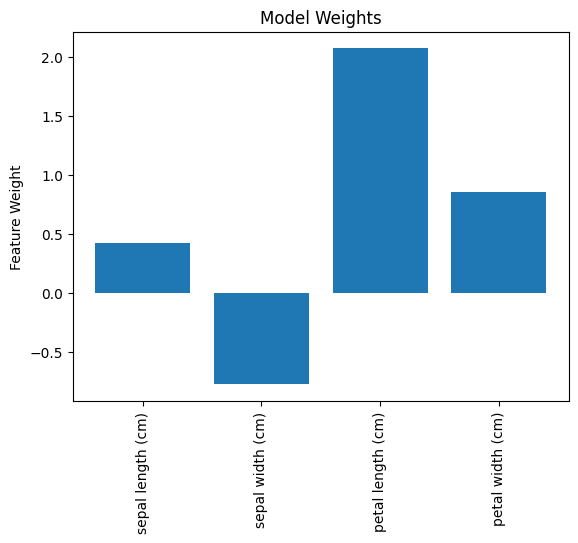

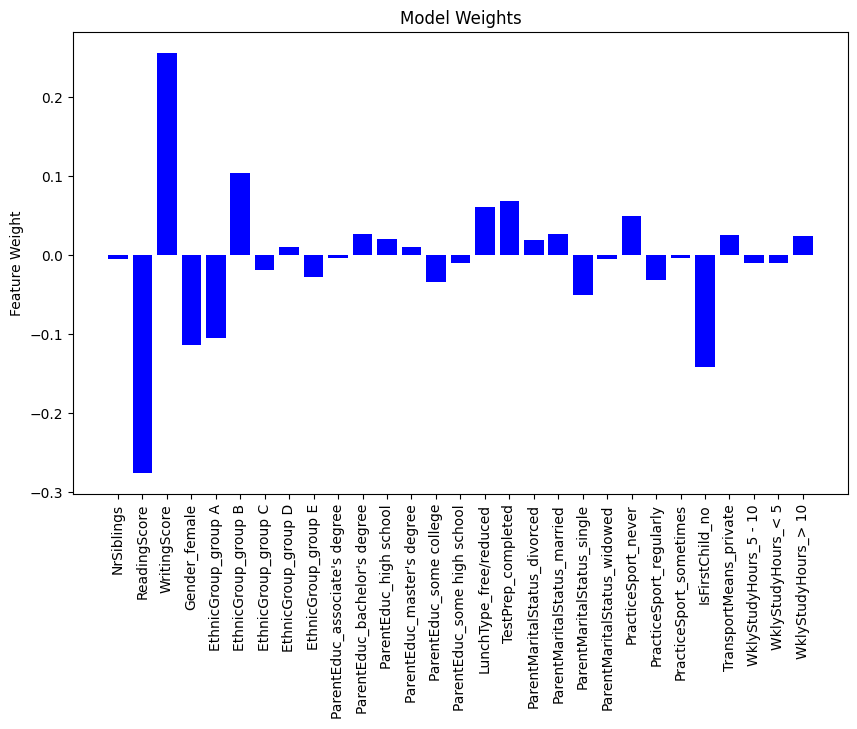

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_weights(model, feature_names):
    weights = model.coef_[0]
    plt.figure(figsize=(10,6))
    plt.bar(np.arange(len(weights)), weights, color= 'blue')
    plt.xticks(np.arange(len(weights)), feature_names, rotation = 90)
    

    plt.ylabel("Feature Weight")
    plt.title("Model Weights")

    plt.show()

plot_model_weights(logreg, feature_names)



### Writing prompt 1: Explain how this model works in 1-3 sentences.  

This model makes a grade classification based on 29 features. The grades are classified according to these labels: 'grade<=90' and 'grade>90', we train this classification model using logistic regression. Its classification is heavily influnced by a handful of features and some make no impact all.

## Practice using and interpreting a LIME explanation from a software package

Use the LimeTabularExplainer in lime_tabular to generate explanations for 10 randomly selected test instances.  Consider using numpy's random.choice function to choose the 10 random instances.  Make sure to save them as a list so you can use them in the next step!

To use the LIME package, read through the documentation here: https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_tabular 

Set the num_features to 5, and the num_samples to 50,000

In [75]:
import lime 
import lime.lime_tabular
import numpy as np 

def explainer(model, trainData, testData, feature_names):
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data= trainData,
        feature_names=feature_names,
        mode = 'classification',
        verbose= True
    )
    index= np.random.choice(testData.shape[0], 10)
    chosenInstances= testData[index]
    explanations = []
    localFeature=[]
    for i in index:
        explanation= lime_explainer.explain_instance(
            data_row = testData[i],
            predict_fn= model.predict_proba,
            num_features = 5,
            num_samples = 50000
        )
        explanations.append(explanation)
        localFeature.append(explanation.as_list())
    return explanations, chosenInstances, localFeature

explanations, chosenInstances, localFeature= explainer(logreg, trainData, testData, feature_names)

for i, features in enumerate(localFeature):
    print("feature importance for instance: ", i)
    for feature, importance in features:
        print(feature, importance)




Intercept 0.5072042479309531
Prediction_local [0.4191478]
Right: 0.4419514447769316
Intercept 0.4621657778523035
Prediction_local [0.46520714]
Right: 0.44863553889810553
Intercept 0.41715067527683686
Prediction_local [0.51141467]
Right: 0.5756787417569897
Intercept 0.45074574245522464
Prediction_local [0.4824636]
Right: 0.479080545391214
Intercept 0.41768690968606587
Prediction_local [0.5116005]
Right: 0.5528360843935223
Intercept 0.46689925494460177
Prediction_local [0.46441479]
Right: 0.4081998685251663
Intercept 0.5074626918895535
Prediction_local [0.42086543]
Right: 0.34821048756400846
Intercept 0.42471898449360745
Prediction_local [0.5080932]
Right: 0.46480825490607564
Intercept 0.46518907963317296
Prediction_local [0.45207906]
Right: 0.35521661000727894
Intercept 0.46160373440056557
Prediction_local [0.46771763]
Right: 0.49465835745155956
feature importance for instance:  0
ReadingScore <= -0.28 0.12383037639715279
WritingScore <= -0.26 -0.11563668765494196
EthnicGroup_group A > 

### Writing prompt 2:  What do these explanations tell you about how this model works?  Explain your response in 1-3 sentences.


These explanations tell me that the decision for a particular label is affected by the weights of the feature(s). For any given instance there is a baseline prediction as to what label it should be assigned to, but as we add weighted features that intercept value adjusts. This gives us the local prediction, this is how the model understands the way to classify the data with information on features and their weights. We compare this value to the right value (this is the actual probabilty that an instance falls into a certain label) to determine how good our model was at assigning a particular instance to a certain label.

### Writing prompt 3:  Explain how you can use these explanations to tell LIME is "working".  Make sure to compare the explanations generated by LIME to the plot of your model's weights to make your argument.  Explain your response in 2-4 sentences.


I can use these explanations to tell that lime is working by looking at how close the Prediction_local is to Right. This tells me that the local explanation does a good job at understaing the model's reasoning for classifing a particular instnance to a label. Compared to the plot the features identified are similar, the lime explanations routinely highlight the features that have the most weight according to the bar plot. This comparison alone shows that when the model takes into account those specific features it has different influences on the prediction for every instance. I can identify that LIME is working because it is clear that different instances use features in different ways, we should expect this.

### Writing prompt 4: Would you use this model?  Do you need additional information to decide?  Explain your response in 2-4 sentences.


I would use this model with a lot of discretion. I think that it is very close to making its prediction align with the actual label output, locally. I would ask for more information though, to be very clear about how accurate (globally) the model is in its deployment. It could be that overall the model is not good at all but locally appears to make good explanations for a models behavior.

## Train a basic neural network and evaluate it

Train a simple neural network on the train dataset.  Use the scikit-learn MLP Classifier.

Set max_iter to 20000.  Otherwise, use default settings.

See the documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html 

Use your print_model_evaluation function to evaluate the model.

In [32]:
from sklearn.neural_network import MLPClassifier 
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=100, random_state =1)

clf = MLPClassifier(random_state=1, max_iter= 20000).fit(trainData, y_train)
clf.predict_proba(testData[:1])
clf.predict(testData[:5, :])
clf.score(testData, y_test)

print_model_evaluation(clf, trainData, y_train, testData, y_test)



The fraction of positive labels in the train set: 0.5033333333333333
The fraction of positive labesl in the test set: 0.5005
The accuracy score for the train set: 0.9993333333333333
The accuracy score for the test set is: 0.718125
The train AUC score is: 0.9999973332148095
The test AUC score is: 0.7754033379033379


## Practice Doing Hyperparameter Selection

Run a hyperparameter search for your neural network where you try different hyperparameters: in this case, numbers and sizes of hidden layers.  You should measure which set of hyperparameters "works best," i.e. has the highest AUC score on the validation set.  Use the best set of hyperparameters to train and evaluate a second neural network model using the print_model_evaluation function.

For all of the models you try, you should set max_iter to 20000.  Try all of the following hidden layer sizes as your hyperparameters:
- 1 hidden layer of size 10  -- hidden_layer_sizes=( 10 )
- 1 hidden layer of size 20 -- hidden_layer_sizes=( 20 )
- 2 hidden layers: the first of size 10 and the second of size 20 -- hidden_layer_sizes=( 10 , 20 )
- 3 hidden layers: the first of size 10, the second of size 20, and the third of size 10 -- hidden_layer_sizes=( 10 , 20 , 20 )


In [41]:
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier 
clf1 = MLPClassifier(hidden_layer_sizes= (10,), random_state=1, max_iter= 20000).fit(trainData, y_train)
auc1= roc_auc_score(y_valid, clf1.predict_proba(validData)[:,1])
print('AUC score for clf1 is:', auc1)
clf2 =MLPClassifier(hidden_layer_sizes= (20,), random_state=1, max_iter= 20000).fit(trainData, y_train)
auc2= roc_auc_score(y_valid, clf2.predict_proba(validData)[:,1])
print('AUC score for clf2 is:', auc2)
clf3 =MLPClassifier(hidden_layer_sizes= (10, 20), random_state=1, max_iter= 20000).fit(trainData, y_train)
auc3 = roc_auc_score(y_valid, clf3.predict_proba(validData)[:,1])
print('AUC score for clf3 is:', auc3)
clf4 = MLPClassifier(hidden_layer_sizes= (10,20,20), random_state=1, max_iter= 20000).fit(trainData, y_train)
auc4= roc_auc_score(y_valid, clf4.predict_proba(validData)[:,1])
print('AUC score for clf4 is:', auc4)

bestConfig= clf3
print_model_evaluation(bestConfig, trainData, y_train, testData, y_test)

AUC score for clf1 is: 0.7934294871794871
AUC score for clf2 is: 0.7915384615384615
AUC score for clf3 is: 0.8075320512820512
AUC score for clf4 is: 0.7759935897435898
The fraction of positive labels in the train set: 0.5033333333333333
The fraction of positive labesl in the test set: 0.5005
The accuracy score for the train set: 0.938
The accuracy score for the test set is: 0.730875
The train AUC score is: 0.9832321436508289
The test AUC score is: 0.8047101172101172


### Writing prompt 5: How does your best model here compare to the first model you trained with 1 hidden layer of size 10?  Do you think it's worth it to do a hyperparameter search?  Will you do one in the future?  Respond in 2-4 sentences.


The best model here, clf3, does just a little bit better than, clf1, this is the 1 hidden layer of size 10. The difference is at most 1000th of a point, I don't know how signigificant that is but generally the bigger the AUC score the better. So even if my best model only out performs the clf1 by a small amount, it still outperforms it. I don't think it is worth it to do a hyperparameter search if we are keeping the activation function the same. I say that because it seems that our model has an AUC that is that doesn't change signifcantly with various hyperparameters. Despite that I do think for learning purposes I will do a hyperparameter search just for the sake of the practice. 

## Practice choosing your own hyperameters

Do a research and come up with another set of hyperparameters to try (consider changing the activation, or trying more variations on hidden layer sizes).  Report the results of your new hyperparameter search.


In [69]:
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier 
clf1 = MLPClassifier(hidden_layer_sizes= (10, 25), random_state=1, max_iter= 20000).fit(trainData, y_train)
auc1= roc_auc_score(y_valid, clf1.predict_proba(validData)[:,1])
print('AUC score for clf1 is:', auc1)
clf2 =MLPClassifier(hidden_layer_sizes= (8,25), random_state=1, max_iter= 20000).fit(trainData, y_train)
auc2= roc_auc_score(y_valid, clf2.predict_proba(validData)[:,1])
print('AUC score for clf2 is:', auc2)
clf3 =MLPClassifier(hidden_layer_sizes= (15, 10), activation= 'tanh', random_state=1, max_iter= 20000).fit(trainData, y_train)
auc3 = roc_auc_score(y_valid, clf3.predict_proba(validData)[:,1])
print('AUC score for clf3 is:', auc3)
clf4 = MLPClassifier(hidden_layer_sizes= (9,30), activation= 'logistic', random_state=1, max_iter= 20000).fit(trainData, y_train)
auc4= roc_auc_score(y_valid, clf4.predict_proba(validData)[:,1])
print('AUC score for clf4 is:', auc4)

bestConfig= clf4
print_model_evaluation(bestConfig, trainData, y_train, testData, y_test)

AUC score for clf1 is: 0.8354807692307692
AUC score for clf2 is: 0.8393910256410256
AUC score for clf3 is: 0.8146634615384615
AUC score for clf4 is: 0.8530929487179486
The fraction of positive labels in the train set: 0.5033333333333333
The fraction of positive labesl in the test set: 0.5005
The accuracy score for the train set: 0.8826666666666667
The accuracy score for the test set is: 0.784625
The train AUC score is: 0.9507809235966043
The test AUC score is: 0.8450234700234699


## Writing prompt 5: How does your best model compare to your previous best model?  What does this tell you about your choice of hyperparameters?  Respond in 2-4 sentences.

Interestingly this best model (logistic) has higher AUC and Accuracy score for the test set but lower scores for the train set compared to the other best model (reLU). This is not good. I think one of the bigger issues is the activiation function and then the choice of hyperparameters. The first hidden layer is pretty small then the second layer is a little more than 3 times as complex. I would guess that there is too much over-fitting becuase the model is too complex for the data set. It seems that having a more moderate and balanced hidden layer size is preferable for this classification scheme.

## Use LIME explanations to interpret a neural network

Repeat the steps to use LIME to explain the best neural network you train (either the one from the first ore second hyperparameter search).  Generate explanations for the same 10 random instances you explained before.

In [77]:
import lime 
import lime.lime_tabular
import numpy as np 

explanations, chosenInstances, localFeatures= explainer(clf4, trainData, testData, feature_names)
for i, features in enumerate(localFeature):
    print("feature importance for instance: ", i)
    for feature, importance in features:
        print(feature, importance)

Intercept 0.5619961122916675
Prediction_local [0.62653068]
Right: 0.9885795044327779
Intercept 0.6716063617525435
Prediction_local [0.56727501]
Right: 0.9684526827557125
Intercept 0.7000679351651238
Prediction_local [0.60818574]
Right: 0.9157561376144541
Intercept 0.5863822016010918
Prediction_local [0.76118518]
Right: 0.13179741564494107
Intercept 0.6306242253444551
Prediction_local [0.72133851]
Right: 0.6479257509177341
Intercept 0.6223317465847849
Prediction_local [0.71650391]
Right: 0.3353528569938762
Intercept 0.585215210398294
Prediction_local [0.83660057]
Right: 0.9412835564676572
Intercept 0.6255860511380626
Prediction_local [0.71952852]
Right: 0.9939263978206375
Intercept 0.7148630830926757
Prediction_local [0.45569358]
Right: 0.14689977006340876
Intercept 0.5546336179725148
Prediction_local [0.60955163]
Right: 0.9715757651855891
feature importance for instance:  0
ReadingScore <= -0.28 0.12383037639715279
WritingScore <= -0.26 -0.11563668765494196
EthnicGroup_group A > -0.28 

### Writing prompt 7: What do these explanations tell you about how this model works?  Respond in 1-3 sentences.

These explanations highlight how poor this model is for the classification scheme. Using the same features that we previously identified, this model does a bad job of using those features to make a local prediction. It really drops the significance of the features for a lot of the instances and this causes the local prediction to be farther from the actual prediction of where an instance falls under a label.

### Writing prompt 8: How do these explanations differ from the explanations for the logistic regression model?  Consider how different the explanations are between different instances.  

These explanations are worse off. The difference between the prediction_local and right value has grown larger for this model. Most of the right values for these instances is near 1, so the instances almost surely fall into a given label. The prediction_local significantly puts those outcome probabilities much lower, meaning it doesnt get assigned to the label we expect it to be in.

### Writing prompt 9:  Would you use this model?  Do you need additional information to decide?  Make sure to compare this response to the response for the logistic regression model.  Explain your response in 2-5 sentences.

I would not use this model given the explanations and analysis that I have done on it. I said that I would use the logistic regression model given that its scores are better across the test and train sets in addition to its prediction_local. This means that both golobally and locally the logistic regression model does a good job at this classification. I think this is becuase the task isn't overwhelmingly complex, but the most recent model I trained was over fitting leading to bad scores.